## Data Loading and First Inspection

In [9]:
import pandas as pd
df = pd.read_csv("google_play_store_dataset.csv")

In [10]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [11]:
df.shape

(10841, 13)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


## Missing Values and Data Quality Checks

In [13]:
df.isna().sum().sort_values(ascending=False)

Rating            1474
Current Ver          8
Android Ver          3
Type                 1
Content Rating       1
App                  0
Category             0
Reviews              0
Size                 0
Installs             0
Price                0
Genres               0
Last Updated         0
dtype: int64

## Data Cleaning and Preparations

In [15]:
# Clean the Installs column safely
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

# Convert to numeric, forcing invalid values to NaN
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Check result
df["Installs"].head()

0       10000.0
1      500000.0
2     5000000.0
3    50000000.0
4      100000.0
Name: Installs, dtype: float64

In [16]:
df[df["Installs"].isna()].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",NaN,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


## Exploratory Data Analysis


In [17]:
import matplotlib.pyplot as plt

df["Installs"].describe()

count    1.084000e+04
mean     1.546434e+07
std      8.502936e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      5.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

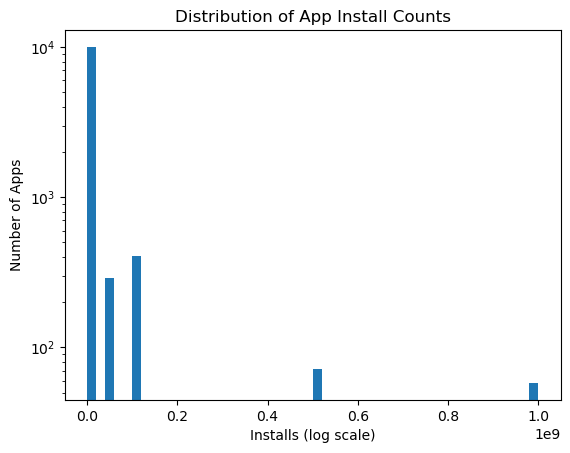

In [18]:
plt.figure()
df["Installs"].dropna().plot(kind="hist", bins=50, log=True)
plt.xlabel("Installs (log scale)")
plt.ylabel("Number of Apps")
plt.title("Distribution of App Install Counts")
plt.show()

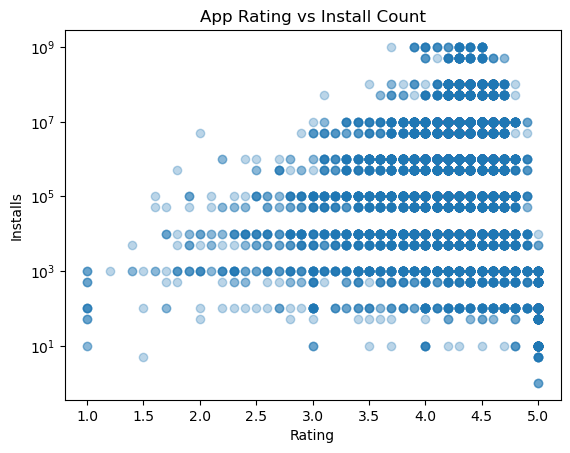

In [19]:
plt.figure()
plt.scatter(df["Rating"], df["Installs"], alpha=0.3)
plt.xlabel("Rating")
plt.ylabel("Installs")
plt.yscale("log")
plt.title("App Rating vs Install Count")
plt.show()

In [20]:
category_installs = (
    df.groupby("Category")["Installs"]
    .median()
    .sort_values(ascending=False)
)

category_installs.head(10)

Category
PHOTOGRAPHY         5000000.0
ENTERTAINMENT       5000000.0
WEATHER             1000000.0
VIDEO_PLAYERS       1000000.0
TRAVEL_AND_LOCAL    1000000.0
SOCIAL              1000000.0
SHOPPING            1000000.0
COMMUNICATION       1000000.0
EDUCATION           1000000.0
GAME                1000000.0
Name: Installs, dtype: float64

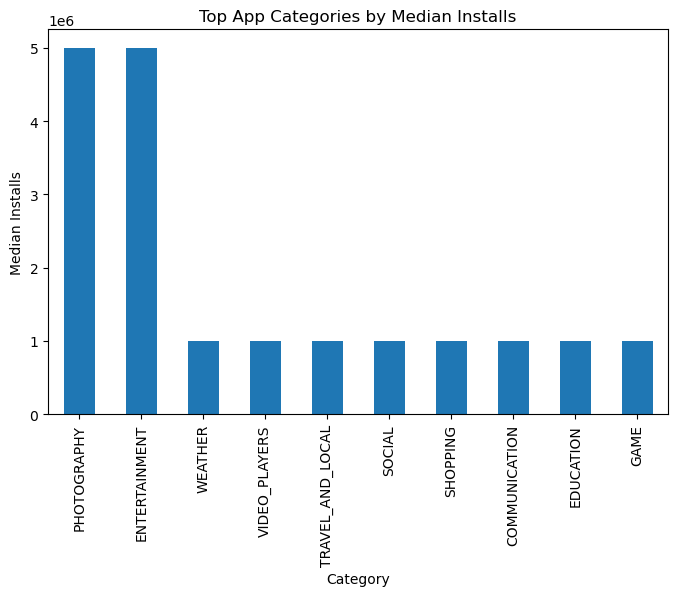

In [21]:
plt.figure(figsize=(8,5))
category_installs.head(10).plot(kind="bar")
plt.ylabel("Median Installs")
plt.title("Top App Categories by Median Installs")
plt.show()